# CSE2530 Computational Intelligence
## Assignment 3: Reinforcement Learning

<div>

_Fill in your group number **from Brightspace**, names, and student numbers._
    
|    Group   |           69          |
|------------|----------------------|
| Luca Rowan Tuluș  |        6154875       |
| Szymon Krętowski  |        6128351       |
| Hristo Bozhkov  |        6142680       |
| Kamil Wawszczak  |        6160395       |

#### Imports

In [1]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import matplotlib.pyplot as plt
import numpy as np
import random
from typing import Dict, List
from tqdm import tqdm

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Agent import Agent
from Maze import Maze
from QTable import QTable
from State import State
from Action import Action

## 2. Navigating in the Supermarket
### 2.1 Development
#### Question 1

In [2]:
class ExplorationStrategy:
    def __init__(self, q_table: QTable):
        self.q_table = q_table

    def random(self, agent: Agent, maze: Maze):
        """
        The random exploration strategy selects a random action uniformly at random
        from the set of all valid actions.
        """
        valid_actions = agent.get_valid_actions(maze)

        if len(valid_actions) == 0:
            return None

        idx = np.random.choice(len(valid_actions))
        return valid_actions[idx]

    def e_greedy(self, agent: Agent,  maze: Maze, eps: float):
        """
        The e-greedy exploration strategy selects a random action with probability eps,
        and the action with highest q-value with probability 1 - eps. A value of epsilon
        close to 0 favours exploitation, while a value close to 1 favours exploration.
        """
        valid_actions = agent.get_valid_actions(maze)

        if len(valid_actions) == 0:
            return None

        # explore
        if np.random.rand() < eps:
            idx = np.random.choice(len(valid_actions))
            return valid_actions[idx]

        # exploit
        current_state = agent.get_state(maze)
        q_values = [self.q_table.get_q(current_state, action) for action in valid_actions]

        max_q = max(q_values)

        best_actions = []
        for action, q_value in zip(valid_actions, q_values):
            if q_value == max_q:
                best_actions.append(action)

        idx = np.random.choice(len(best_actions))
        return best_actions[idx]


    def boltzmann(self, agent: Agent, maze: Maze, temperature: float):
        """
        The Boltzmann exploration strategy assigns a probability to each action based on its estimated q-values.
        A large value of the temperature encourages exploration, and as the temperature declines over time,
        exploitation is favoured. 
        """
        valid_actions = agent.get_valid_actions(maze)

        if len(valid_actions) == 0:
            return None

        current_state = agent.get_state(maze)
        q_values = np.array([self.q_table.get_q(current_state, action) for action in valid_actions], dtype=float)

        # prevent division by zero
        if temperature <= 0:
            temperature = 1e-8

        # numerically stable softmax
        q_values = q_values - np.max(q_values)
        probs = np.exp(q_values / temperature)
        probs = probs / np.sum(probs)

        idx = np.random.choice(len(valid_actions), p=probs)
        return valid_actions[idx]


<div>

**Answer :**

We implemented three exploration strategies: **random**, **$\varepsilon$-greedy**, and **Boltzmann**.

In the **random** strategy, the agent chooses one of the valid actions uniformly at random. This gives full exploration, because every valid move has the same probability of being selected. However, it does not use any information from the Q-table, so it cannot exploit what has already been learned.

In the **$\varepsilon$-greedy** strategy, the agent chooses a random valid action with probability $\varepsilon$, and with probability $1 - \varepsilon$ it chooses the valid action with the highest Q-value. If multiple actions have the same highest Q-value, we choose randomly between them. This makes the strategy simple but effective, because it still allows exploration while also using the current Q-values to exploit good actions.

In the **Boltzmann** strategy, the agent assigns a probability to each valid action based on its Q-value using the softmax formula. Actions with higher Q-values become more likely, but lower-valued actions can still be selected as well. Compared to $\varepsilon$-greedy, this makes the exploration smoother, because the action probabilities change gradually depending on how good the actions currently seem.

For the initial hyper-parameter values, we chose values that encourage exploration at the start, for example a relatively high $\varepsilon$ and a relatively high temperature $T$. At the beginning, the agent does not know anything about the maze, so it needs enough exploration to discover useful paths and rewards.

To deal with the exploration–exploitation trade-off, we use more exploration early in training and more exploitation later. This is a sensible choice, because in the beginning the agent needs to collect information about the environment, while later it should use the learned Q-values more often to move efficiently toward the goal. So over time, we reduce $\varepsilon$ or $T$ such that the agent gradually shifts from exploring to exploiting.

#### Question 2

In [3]:
# Create a Maze instance.
maze = Maze("./../data/easy_maze.txt")
maze.set_reward(x=9, y=9, reward=10)
maze.set_terminal(x=9, y=9)
# Create an Agent.
agent = Agent(start_x=0, start_y=0)
# Create a QTable.
states = maze.get_all_states()
actions = [Action(id) for id in ["up", "down", "left", "right"]]
q_table = QTable(states, actions)
# Create an ExplorationStrategy.
exploration_strategy = ExplorationStrategy(q_table)
# Create a learner.
params = {"lr": 0.7, "gamma": 0.9}
#learner = QLearning(q_table, params)

# Hyper-parameters.
n_episodes = 300
episode_lengths = []
episode_rewards = []
max_steps_per_episode = 500

for episode in tqdm(range(n_episodes)):
    agent.reset()

    total_reward = 0
    done = False
    step_count = 0

    while not done and step_count < max_steps_per_episode:
        # 1. observe current state
        state = agent.get_state(maze)

        # 2. choose action
        action = exploration_strategy.e_greedy(agent, maze, eps=0.1)

        # safety check in case no valid action exists
        if action is None:
            break

        # 3. execute action
        next_state, reward, done = agent.step(action, maze)

        # 4. choose next action if needed (for SARSA later)
        next_action = None
        if not done:
            next_action = exploration_strategy.e_greedy(agent, maze, eps=0.1)

        # 5. update q-table
        #learner.learn(state, action, reward, next_state, next_action, done)

        # 6. bookkeeping
        total_reward += reward
        step_count += 1

    episode_lengths.append(step_count)
    episode_rewards.append(total_reward)

100%|██████████| 300/300 [00:01<00:00, 210.40it/s]


<div>

**Answer :**

We implemented the full cycle of one reinforcement learning episode. At the beginning of each episode, the agent is reset to the starting position. Then, as long as the episode has not ended, the agent first observes its current state, chooses an action using the selected exploration strategy, and executes that action in the maze. After this step, it receives the immediate reward and moves to the next state.

This cycle is necessary because reinforcement learning works through repeated interaction with the environment. The current state is needed so the agent knows where it is, the action determines how it moves, and the reward together with the next state provides the information that is later needed to update the Q-table. In the case of SARSA, the next action is also part of the cycle, because the update depends on the action actually chosen in the next state.

We also keep track of some bookkeeping values, such as the total reward collected in the episode and the number of steps taken. These values are not part of the learning rule itself, but they are useful later for analysing the behaviour of the agent, for example when comparing runs or making plots.

At this point, the agent does not yet learn meaningful q-values, because the learn() methods are implemented later. Still, the interaction cycle itself is already complete. It collects all the information in the right order and allows the agent to perform full trials from the start state until termination. No extra steps are needed, because the basic loop in this problem is simply: observe state, choose action, execute action, receive reward and next state, and repeat until the episode ends.

#### Question 3

In [4]:
# Create a Maze instance.
maze = Maze("../data/toy_maze.txt")
maze.set_reward(x=9, y=9, reward=10)
maze.set_terminal(x=9, y=9)

# Create an Agent.
agent = Agent(start_x=0, start_y=0)

# Create a QTable.
states = maze.get_all_states()
actions = [Action(i) for i in ["up", "down", "left", "right"]]
q_table = QTable(states, actions)

# Create an ExplorationStrategy.
exploration_strategy = ExplorationStrategy(q_table)

# Stopping criterion
n = 30000
total_steps = 0
max_steps_per_episode = 500

# Some bookkeeping
episode_lengths = []
episode_rewards = []
episode_count = 0

# Keep running episodes until total number of steps reaches n
while total_steps < n:
    agent.reset()
    done = False
    episode_reward = 0
    episode_steps = 0

    while not done and total_steps < n and episode_steps < max_steps_per_episode:
        state = agent.get_state(maze)
        action = exploration_strategy.e_greedy(agent, maze, eps=0.1)

        if action is None:
            break

        next_state, reward, done = agent.step(action, maze)

        episode_reward += reward
        episode_steps += 1
        total_steps += 1

    episode_lengths.append(episode_steps)
    episode_rewards.append(episode_reward)
    episode_count += 1

print("Total number of steps:", total_steps)
print("Number of episodes completed:", episode_count)
print("Last episode length:", episode_lengths[-1])
assert total_steps == 30000

Total number of steps: 30000
Number of episodes completed: 66
Last episode length: 150


<div>

**Answer :**

We implemented the stopping criterion by keeping track of the total number of steps over all episodes in the variable total_steps. After every action taken by the agent, this counter is increased by 1. The run continues only while total_steps < 30000, so the stopping condition depends on the total number of steps across all episodes, not on the number of episodes.

Inside each episode, we also count the number of steps taken in that episode. This makes it possible to stop an episode either when the agent reaches a terminal state, when the maximum number of steps for that episode is reached, or when the total number of steps over the full run reaches 30000.

We verified that the stopping criterion works correctly in two ways. First, we printed the final value of total_steps, and this gave exactly 30000. Second, we used the statement assert total_steps == 30000, which automatically checks that the agent stops exactly at the required number of total steps.

#### Question 4

In [5]:
def run_agent_without_learning(maze_path, total_step_limit, max_steps_per_episode=500, eps=0.1):
    # Create maze
    maze = Maze(maze_path)
    maze.set_reward(x=maze.width - 1, y=maze.height - 1, reward=10)
    maze.set_terminal(x=maze.width - 1, y=maze.height - 1)

    # Create agent
    agent = Agent(start_x=0, start_y=0)

    # Create q-table and exploration strategy
    states = maze.get_all_states()
    actions = [Action(i) for i in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    exploration_strategy = ExplorationStrategy(q_table)

    total_steps = 0
    episode_lengths = []

    while total_steps < total_step_limit:
        agent.reset()
        done = False
        episode_steps = 0

        while not done and total_steps < total_step_limit and episode_steps < max_steps_per_episode:
            action = exploration_strategy.random(agent, maze)
            if action is None:
                break

            next_state, reward, done = agent.step(action, maze)

            episode_steps += 1
            total_steps += 1

        episode_lengths.append(episode_steps)

    return episode_lengths

In [6]:
n_runs = 10

toy_runs = []
easy_runs = []

for i in range(n_runs):
    toy_episode_lengths = run_agent_without_learning(
        maze_path="../data/toy_maze.txt",
        total_step_limit=30000,
        max_steps_per_episode=500,
        eps=0.1
    )
    toy_runs.append(toy_episode_lengths)
    print(f"Toy maze run {i+1}: {toy_episode_lengths}")

for i in range(n_runs):
    easy_episode_lengths = run_agent_without_learning(
        maze_path="../data/easy_maze.txt",
        total_step_limit=60000,
        max_steps_per_episode=1000,
        eps=0.1
    )
    easy_runs.append(easy_episode_lengths)
    print(f"Easy maze run {i+1}: {easy_episode_lengths}")

Toy maze run 1: [500, 500, 278, 500, 500, 280, 500, 254, 500, 500, 500, 254, 500, 500, 500, 500, 234, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 304, 150, 480, 500, 500, 500, 500, 234, 500, 208, 500, 500, 388, 500, 500, 500, 500, 500, 500, 220, 500, 428, 368, 500, 500, 240, 500, 500, 500, 500, 500, 500, 500, 500, 500, 282, 402, 500, 496]
Toy maze run 2: [408, 500, 426, 500, 500, 500, 500, 390, 168, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 116, 500, 500, 500, 500, 384, 226, 500, 500, 500, 278, 500, 376, 500, 418, 370, 500, 274, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 424, 202, 500, 500, 500, 500, 500, 500, 166, 374]
Toy maze run 3: [500, 500, 500, 500, 182, 218, 500, 500, 500, 500, 500, 500, 500, 500, 300, 340, 274, 226, 500, 500, 500, 500, 394, 500, 500, 500, 428, 500, 336, 500, 500, 500, 500, 500, 500, 500, 324, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 318, 144, 500, 396, 500, 500, 500, 318, 500,

In [7]:
def plot_average_episode_lengths(all_runs, title):
    max_len = max(len(run) for run in all_runs)

    data = np.full((len(all_runs), max_len), np.nan)

    for i, run in enumerate(all_runs):
        data[i, :len(run)] = run

    mean_vals = np.nanmean(data, axis=0)
    std_vals = np.nanstd(data, axis=0)
    counts = np.sum(~np.isnan(data), axis=0)

    x = np.arange(1, max_len + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(x, mean_vals, label="Average episode length")
    plt.fill_between(
        x,
        mean_vals - std_vals,
        mean_vals + std_vals,
        alpha=0.3,
        label="±1 standard deviation"
    )
    plt.xlabel("Episode number")
    plt.ylabel("Average number of steps")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    return mean_vals, std_vals, counts

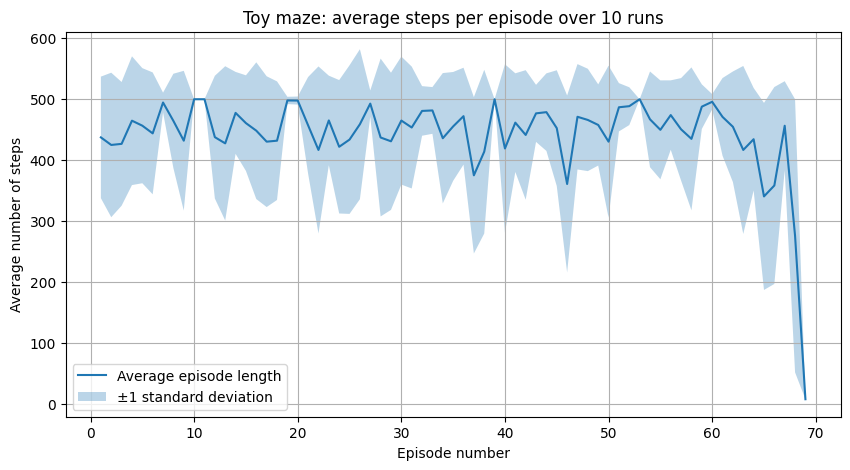

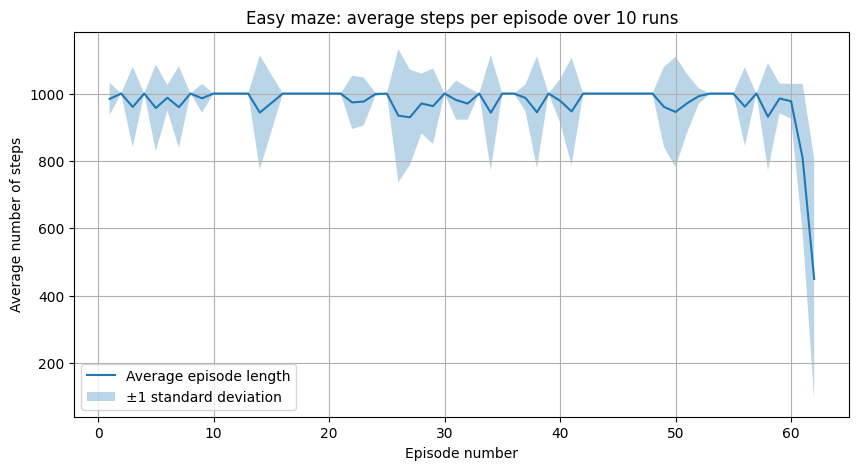

In [8]:
toy_mean, toy_std, toy_counts = plot_average_episode_lengths(
    toy_runs,
    "Toy maze: average steps per episode over 10 runs"
)

easy_mean, easy_std, easy_counts = plot_average_episode_lengths(
    easy_runs,
    "Easy maze: average steps per episode over 10 runs"
)

<div>

**Answer :**

We ran the agent 10 times on both the toy maze and the easy maze, and for each run we recorded how many steps were taken in every episode. At this stage, the learning step is still not implemented, so the Q-table does not change during training. Because of that, we do not expect the agent to improve over time.

The plots show the average number of steps per episode over the 10 runs. Since different runs can have different numbers of episodes, we padded the shorter runs with NaN values and then computed the mean and standard deviation only over the runs that still had data for that episode number. The shaded area in the plots shows one standard deviation, so it gives an indication of the variation and uncertainty between runs.

From both plots, we can see that the average number of steps does not show a clear downward trend. Instead, the curves stay roughly flat and fluctuate over time. This means that the agent is not learning a better policy, which is exactly what we expect when the Q-values are never updated.

The easy maze generally has higher episode lengths than the toy maze, which also makes sense because it is larger and harder to navigate. There is a visible drop near the end of the curves, but we do not interpret this as learning. The last episode numbers are based on fewer runs, so those points are less stable and more affected by randomness.

Overall, the plots support the conclusion that the agent does not learn at this stage.

#### Question 5

In [12]:
class QLearning:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params

    def learn(self, possible_actions: List[Action], state: State, action: Action,
               next_state: State, reward: int, done: bool) -> None:
        
        alpha = self.params["lr"]
        gamma = self.params["gamma"]

        current_q = self.q_table.get_q(state, action)

        if done:
            target = reward
        else:
            max_next_q = max([self.q_table.get_q(next_state, a) for a in possible_actions])
            target = reward + gamma * max_next_q

        new_q = current_q + alpha * (target - current_q)
        self.q_table.set_q(state, action, new_q)

In [13]:
class SARSA:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params
    
    def learn(self, state: State, action: Action, next_state: State, next_action: Action,
               reward: float, done: bool) -> None:
        
        alpha = self.params["lr"]
        gamma = self.params["gamma"]

        current_q = self.q_table.get_q(state, action)

        if done:
            target = reward
        else:
            next_q = self.q_table.get_q(next_state, next_action)
            target = reward + gamma * next_q

        new_q = current_q + alpha * (target - current_q)
        self.q_table.set_q(state, action, new_q)

In [14]:
# -----------------------------
# Sanity checks for Q-learning and SARSA updates
# -----------------------------

class DummyQTable:
    def __init__(self):
        self.values = {}

    def get_q(self, state, action):
        return self.values.get((state, action), 0.0)

    def set_q(self, state, action, value):
        self.values[(state, action)] = value


# Common parameters
params = {"lr": 0.7, "gamma": 0.9}

# ---------------------------------
# Test 1: Q-learning non-terminal
# ---------------------------------
q_table = DummyQTable()
q_table.set_q("s", "a", 2.0)
q_table.set_q("s_next", "up", 5.0)
q_table.set_q("s_next", "down", 3.0)

ql = QLearning(q_table, params)
ql.learn(
    possible_actions=["up", "down"],
    state="s",
    action="a",
    next_state="s_next",
    reward=1,
    done=False
)

expected = 2.0 + 0.7 * ((1 + 0.9 * 5.0) - 2.0)
actual = q_table.get_q("s", "a")

print("Q-learning non-terminal:")
print("Expected:", expected)
print("Actual:  ", actual)
assert abs(actual - expected) < 1e-9


# ---------------------------------
# Test 2: Q-learning terminal
# ---------------------------------
q_table = DummyQTable()
q_table.set_q("s", "a", 2.0)

ql = QLearning(q_table, params)
ql.learn(
    possible_actions=[],
    state="s",
    action="a",
    next_state="terminal",
    reward=10,
    done=True
)

expected = 2.0 + 0.7 * (10 - 2.0)
actual = q_table.get_q("s", "a")

print("\nQ-learning terminal:")
print("Expected:", expected)
print("Actual:  ", actual)
assert abs(actual - expected) < 1e-9


# ---------------------------------
# Test 3: SARSA non-terminal
# ---------------------------------
q_table = DummyQTable()
q_table.set_q("s", "a", 2.0)
q_table.set_q("s_next", "next_a", 4.0)

sarsa = SARSA(q_table, params)
sarsa.learn(
    state="s",
    action="a",
    next_state="s_next",
    next_action="next_a",
    reward=1,
    done=False
)

expected = 2.0 + 0.7 * ((1 + 0.9 * 4.0) - 2.0)
actual = q_table.get_q("s", "a")

print("\nSARSA non-terminal:")
print("Expected:", expected)
print("Actual:  ", actual)
assert abs(actual - expected) < 1e-9


# ---------------------------------
# Test 4: SARSA terminal
# ---------------------------------
q_table = DummyQTable()
q_table.set_q("s", "a", 2.0)

sarsa = SARSA(q_table, params)
sarsa.learn(
    state="s",
    action="a",
    next_state="terminal",
    next_action=None,
    reward=10,
    done=True
)

expected = 2.0 + 0.7 * (10 - 2.0)
actual = q_table.get_q("s", "a")

print("\nSARSA terminal:")
print("Expected:", expected)
print("Actual:  ", actual)
assert abs(actual - expected) < 1e-9


print("\nAll sanity checks passed.")

Q-learning non-terminal:
Expected: 4.449999999999999
Actual:   4.449999999999999

Q-learning terminal:
Expected: 7.6
Actual:   7.6

SARSA non-terminal:
Expected: 3.8199999999999994
Actual:   3.8199999999999994

SARSA terminal:
Expected: 7.6
Actual:   7.6

All sanity checks passed.


<div>

**Answer :**

We implemented the learn() methods for both Q-learning and SARSA using the update equations from the assignment. In both methods, we use the learning rate (alpha = 0.7) and discount factor (gamma = 0.9). The parameter (varepsilon = 0.1) is used in the exploration strategy, not directly inside the learning update itself

For Q-learning, we update the q-value of the current state-action pair by using the reward plus the discounted value of the best possible next action. So even if the agent does not actually choose the best next action, Q-learning still learns toward that greedy target. Because of this, Q-learning is called an off-policy method

For SARSA, we also update the q-value of the current state-action pair, but now we use the reward plus the discounted value of the actual next action selected by the policy. This means the update depends on the behaviour of the current exploration strategy. Because of that, SARSA is and on-policy method

In both implementations, if the next state is terminal, we do not add a future q-value term anymore. In that case, the update target is just the immediate reward. This is necessary because once the terminal state is reached, the episode ends and there is no next action value to propagate

The main difference between the two methods is therefore in the target they use. Q-learning looks at the maximum q-value in the next state, while SARSA looks at the q-value of the next action that was really chosen. This usually makes Q-learning more optimistic and greedy, while SARSA tends to be more conservative because it learns according to the current policy, including exploration

#### Question 6

In [15]:
def run_qlearning(maze_path, total_step_limit, max_steps_per_episode=500, eps=0.1):
    maze = Maze(maze_path)
    maze.set_reward(x=maze.width - 1, y=maze.height - 1, reward=10)
    maze.set_terminal(x=maze.width - 1, y=maze.height - 1)

    agent = Agent(start_x=0, start_y=0)

    states = maze.get_all_states()
    actions = [Action(i) for i in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    exploration_strategy = ExplorationStrategy(q_table)

    params = {"lr": 0.7, "gamma": 0.9}
    learner = QLearning(q_table, params)

    total_steps = 0
    episode_lengths = []

    while total_steps < total_step_limit:
        agent.reset()
        done = False
        episode_steps = 0

        while not done and total_steps < total_step_limit and episode_steps < max_steps_per_episode:
            state = agent.get_state(maze)
            action = exploration_strategy.e_greedy(agent, maze, eps=eps)

            if action is None:
                break

            next_state, reward, done = agent.step(action, maze)

            possible_actions = agent.get_valid_actions(maze)
            learner.learn(possible_actions, state, action, next_state, reward, done)

            episode_steps += 1
            total_steps += 1

        episode_lengths.append(episode_steps)

    return episode_lengths

In [16]:
def run_sarsa(maze_path, total_step_limit, max_steps_per_episode=500, eps=0.1):
    maze = Maze(maze_path)
    maze.set_reward(x=maze.width - 1, y=maze.height - 1, reward=10)
    maze.set_terminal(x=maze.width - 1, y=maze.height - 1)

    agent = Agent(start_x=0, start_y=0)

    states = maze.get_all_states()
    actions = [Action(i) for i in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    exploration_strategy = ExplorationStrategy(q_table)

    params = {"lr": 0.7, "gamma": 0.9}
    learner = SARSA(q_table, params)

    total_steps = 0
    episode_lengths = []

    while total_steps < total_step_limit:
        agent.reset()
        done = False
        episode_steps = 0

        state = agent.get_state(maze)
        action = exploration_strategy.e_greedy(agent, maze, eps=eps)

        while not done and total_steps < total_step_limit and episode_steps < max_steps_per_episode:
            if action is None:
                break

            next_state, reward, done = agent.step(action, maze)

            next_action = None
            if not done:
                next_action = exploration_strategy.e_greedy(agent, maze, eps=eps)

            learner.learn(state, action, next_state, next_action, reward, done)

            state = next_state
            action = next_action

            episode_steps += 1
            total_steps += 1

        episode_lengths.append(episode_steps)

    return episode_lengths

In [17]:
def plot_average_episode_lengths(all_runs, title):
    max_len = max(len(run) for run in all_runs)

    data = np.full((len(all_runs), max_len), np.nan)

    for i, run in enumerate(all_runs):
        data[i, :len(run)] = run

    mean_vals = np.nanmean(data, axis=0)
    std_vals = np.nanstd(data, axis=0)

    x = np.arange(1, max_len + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(x, mean_vals, label="Average episode length")
    plt.fill_between(
        x,
        mean_vals - std_vals,
        mean_vals + std_vals,
        alpha=0.3,
        label="±1 standard deviation"
    )
    plt.xlabel("Episode number")
    plt.ylabel("Average number of steps")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    return mean_vals, std_vals

In [18]:
n_runs = 10

q_toy_runs = []
q_easy_runs = []
sarsa_toy_runs = []
sarsa_easy_runs = []

for i in range(n_runs):
    q_toy_runs.append(
        run_qlearning("../data/toy_maze.txt", total_step_limit=30000, max_steps_per_episode=500, eps=0.1)
    )
    print(f"Q-learning toy run {i+1} done")

for i in range(n_runs):
    q_easy_runs.append(
        run_qlearning("../data/easy_maze.txt", total_step_limit=300000, max_steps_per_episode=2000, eps=0.1)    
    )
    print(f"Q-learning easy run {i+1} done")

for i in range(n_runs):
    sarsa_toy_runs.append(
        run_sarsa("../data/toy_maze.txt", total_step_limit=30000, max_steps_per_episode=500, eps=0.1)
    )
    print(f"SARSA toy run {i+1} done")

for i in range(n_runs):
    sarsa_easy_runs.append(
        run_sarsa("../data/easy_maze.txt", total_step_limit=300000, max_steps_per_episode=2000, eps=0.1)
    )
    print(f"SARSA easy run {i+1} done")

Q-learning toy run 1 done
Q-learning toy run 2 done
Q-learning toy run 3 done
Q-learning toy run 4 done
Q-learning toy run 5 done
Q-learning toy run 6 done
Q-learning toy run 7 done
Q-learning toy run 8 done
Q-learning toy run 9 done
Q-learning toy run 10 done
Q-learning easy run 1 done
Q-learning easy run 2 done
Q-learning easy run 3 done
Q-learning easy run 4 done
Q-learning easy run 5 done
Q-learning easy run 6 done
Q-learning easy run 7 done
Q-learning easy run 8 done
Q-learning easy run 9 done
Q-learning easy run 10 done
SARSA toy run 1 done
SARSA toy run 2 done
SARSA toy run 3 done
SARSA toy run 4 done
SARSA toy run 5 done
SARSA toy run 6 done
SARSA toy run 7 done
SARSA toy run 8 done
SARSA toy run 9 done
SARSA toy run 10 done
SARSA easy run 1 done
SARSA easy run 2 done
SARSA easy run 3 done
SARSA easy run 4 done
SARSA easy run 5 done
SARSA easy run 6 done
SARSA easy run 7 done
SARSA easy run 8 done
SARSA easy run 9 done
SARSA easy run 10 done


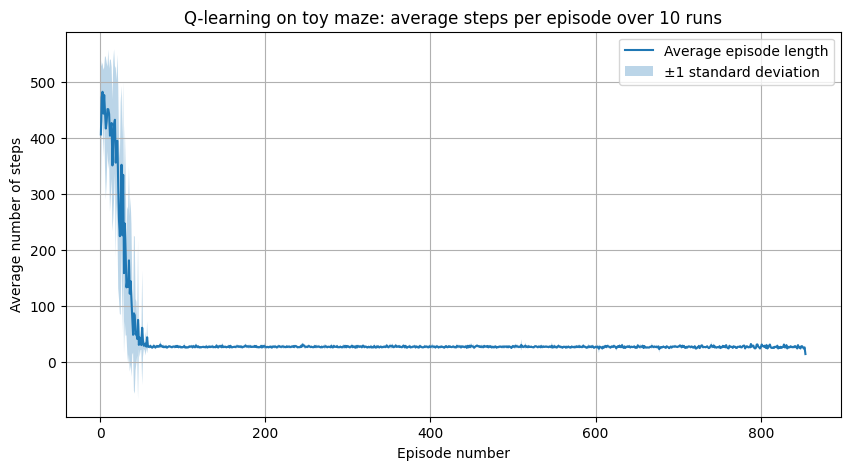

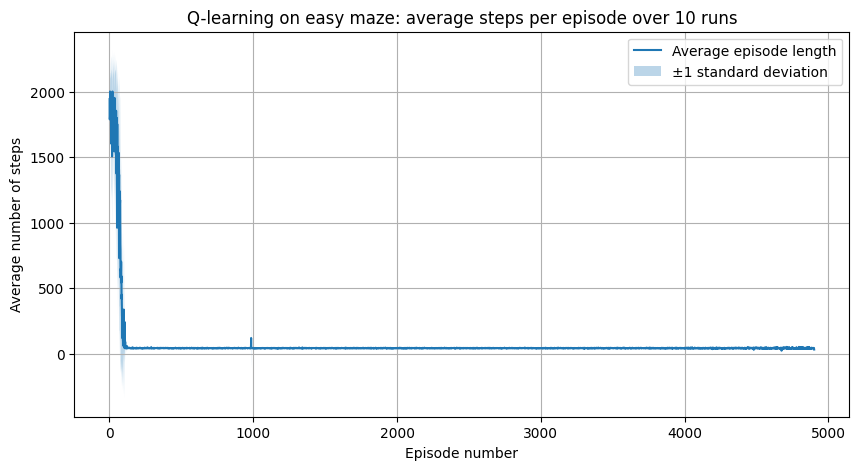

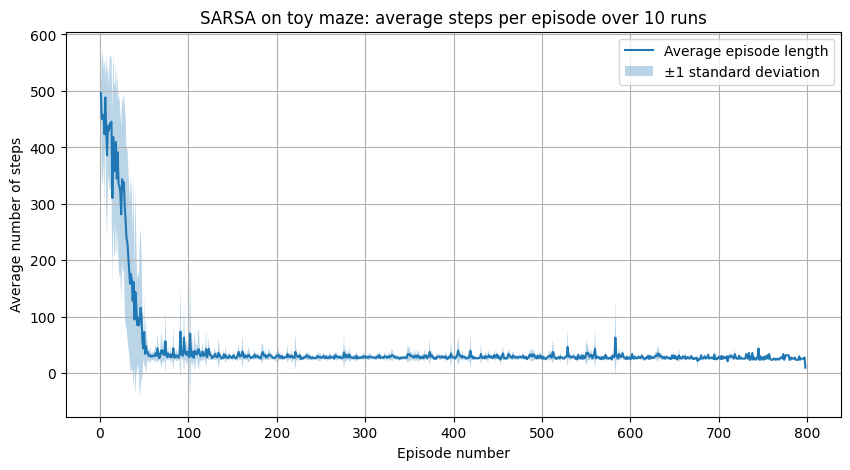

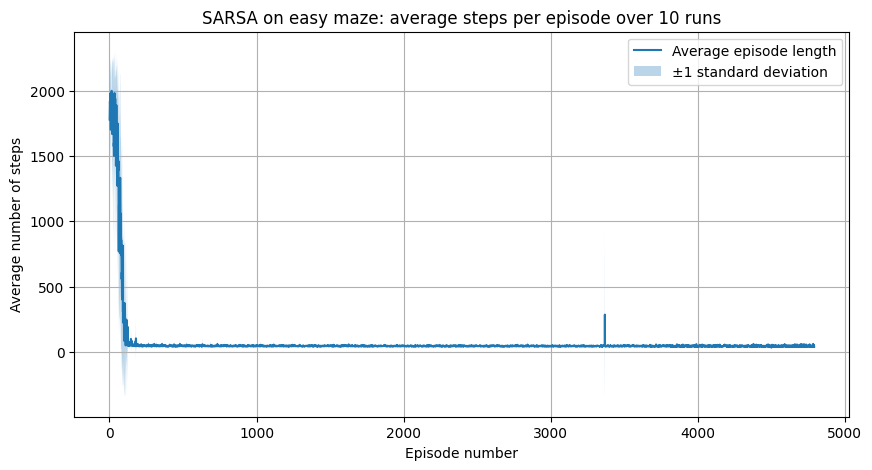

(array([1780.6, 1840.4, 1920.6, ...,   40. ,   46. ,   40. ], shape=(4791,)),
 array([445.11036834, 478.8       , 192.93117944, ...,   0.        ,
          0.        ,   0.        ], shape=(4791,)))

In [19]:
plot_average_episode_lengths(q_toy_runs, "Q-learning on toy maze: average steps per episode over 10 runs")
plot_average_episode_lengths(q_easy_runs, "Q-learning on easy maze: average steps per episode over 10 runs")
plot_average_episode_lengths(sarsa_toy_runs, "SARSA on toy maze: average steps per episode over 10 runs")
plot_average_episode_lengths(sarsa_easy_runs, "SARSA on easy maze: average steps per episode over 10 runs")

<div>

**Answer :**

For this question, we ran both Q-learning and SARSA 10 times on both the toy maze and the easy maze. For each run, we recorded the number of steps taken in every episode and then plotted the average episode length over the 10 runs. We also included one standard deviation as an indication of uncertainty. Since different runs can have different numbers of episodes, we padded shorter runs with missing values and computed the mean and standard deviation only over the runs that still had data for that episode number.

The plots clearly show that the agent does learn. In all four cases, the average number of steps per episode is high at the beginning and then decreases strongly over time before stabilizing at a much lower value. This means that in later episodes the agent reaches the goal in fewer steps than in the earlier episodes. So we can conclude that the Q-values are being updated in a useful way and that the agent is learning a better policy.

The uncertainty is also larger at the start and becomes much smaller later on. This makes sense, because in the beginning the agent still explores a lot and behaves less consistently. Once it has learned better state-action values, its behaviour becomes more stable, so the variation between runs also decreases.

For the toy maze, both algorithms learn quite quickly and reach low episode lengths after relatively few episodes. For the easy maze, learning takes longer, but the same overall pattern is still visible: the average number of steps eventually drops a lot and then stays low. This is expected, because the easy maze is larger and needs more exploration before the reward information can spread through the Q-table.

Comparing the two methods, both Q-learning and SARSA are able to learn the environment. Q-learning seems a bit more aggressive, while SARSA looks slightly more conservative, but in both cases the plots show clear improvement over time.

Overall, these plots show that once the learning updates are implemented, the agent really does learn the environment, because later episodes require far fewer steps than the first episodes.

#### Question 7

<div>

<div>

**Answer :**

Yes, we do observe some differences between robots trained with Q-learning and SARSA, even though in our experiments both methods were able to learn successfully.

From the plots, both algorithms show the same general behaviour: the average number of steps per episode decreases strongly over time, which means that both agents improve. However, Q-learning seems a bit more aggressive, because it reaches low episode lengths slightly more directly. SARSA also learns well, but its curve looks a bit more cautious and sometimes a little noisier before it stabilizes.

The reason for this difference comes from the update equations. In Q-learning, the update uses the value of the **best possible next action**. So even if the agent actually takes an exploratory action, the update still assumes that the best next action will be chosen. Because of this, Q-learning is called **off-policy** and usually learns in a more optimistic way.

In SARSA, the update uses the value of the **next action that was actually chosen**. Since this next action comes from the current policy, SARSA learns according to the real behaviour of the agent, including exploration. That is why SARSA is called **on-policy** and is usually a bit more conservative.

So the main difference is that Q-learning learns toward a greedy target, while SARSA learns toward the action that is really taken. This explains why Q-learning often looks slightly faster or more aggressive, while SARSA can look a bit more careful. In our plots, this difference is visible, but both methods still clearly learn the maze.

### 2.2 Optimization
#### Question 8

In [20]:
def run_qlearning_with_epsilon(maze_path, total_step_limit, eps, max_steps_per_episode=500):
    maze = Maze(maze_path)
    maze.set_reward(x=maze.width - 1, y=maze.height - 1, reward=10)
    maze.set_terminal(x=maze.width - 1, y=maze.height - 1)

    agent = Agent(start_x=0, start_y=0)

    states = maze.get_all_states()
    actions = [Action(i) for i in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions, initial_value=100)

    exploration_strategy = ExplorationStrategy(q_table)

    params = {"lr": 0.7, "gamma": 0.9}
    learner = QLearning(q_table, params)

    total_steps = 0
    episode_lengths = []

    while total_steps < total_step_limit:
        agent.reset()
        done = False
        episode_steps = 0

        while not done and total_steps < total_step_limit and episode_steps < max_steps_per_episode:
            state = agent.get_state(maze)
            action = exploration_strategy.e_greedy(agent, maze, eps=eps)

            if action is None:
                break

            next_state, reward, done = agent.step(action, maze)

            possible_actions = agent.get_valid_actions(maze)
            learner.learn(possible_actions, state, action, next_state, reward, done)

            episode_steps += 1
            total_steps += 1

        episode_lengths.append(episode_steps)

    return episode_lengths

In [25]:
def plot_multiple_epsilons(epsilon_runs_dict, title, max_episode=None):
    plt.figure(figsize=(11, 6))

    for eps, all_runs in epsilon_runs_dict.items():
        max_len = max(len(run) for run in all_runs)
        data = np.full((len(all_runs), max_len), np.nan)

        for i, run in enumerate(all_runs):
            data[i, :len(run)] = run

        mean_vals = np.nanmean(data, axis=0)
        x = np.arange(1, max_len + 1)

        if max_episode is not None:
            x = x[:max_episode]
            mean_vals = mean_vals[:max_episode]

        plt.plot(x, mean_vals, label=f"$\\varepsilon = {eps}$")

    plt.xlabel("Episode number")
    plt.ylabel("Average number of steps")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [26]:
eps_values = [0.0, 0.05, 0.1, 0.3, 0.7]
n_runs = 10

toy_eps_runs = {}

for eps in eps_values:
    toy_eps_runs[eps] = []
    for i in range(n_runs):
        run = run_qlearning_with_epsilon(
            maze_path="../data/toy_maze.txt",
            total_step_limit=30000,
            eps=eps,
            max_steps_per_episode=500
        )
        toy_eps_runs[eps].append(run)
    print(f"Finished toy maze for eps = {eps}")

Finished toy maze for eps = 0.0
Finished toy maze for eps = 0.05
Finished toy maze for eps = 0.1
Finished toy maze for eps = 0.3
Finished toy maze for eps = 0.7


In [23]:
easy_eps_runs = {}

for eps in eps_values:
    easy_eps_runs[eps] = []
    for i in range(n_runs):
        run = run_qlearning_with_epsilon(
            maze_path="../data/easy_maze.txt",
            total_step_limit=300000,
            eps=eps,
            max_steps_per_episode=2000
        )
        easy_eps_runs[eps].append(run)
    print(f"Finished easy maze for eps = {eps}")

Finished easy maze for eps = 0.0
Finished easy maze for eps = 0.05
Finished easy maze for eps = 0.1
Finished easy maze for eps = 0.3
Finished easy maze for eps = 0.7


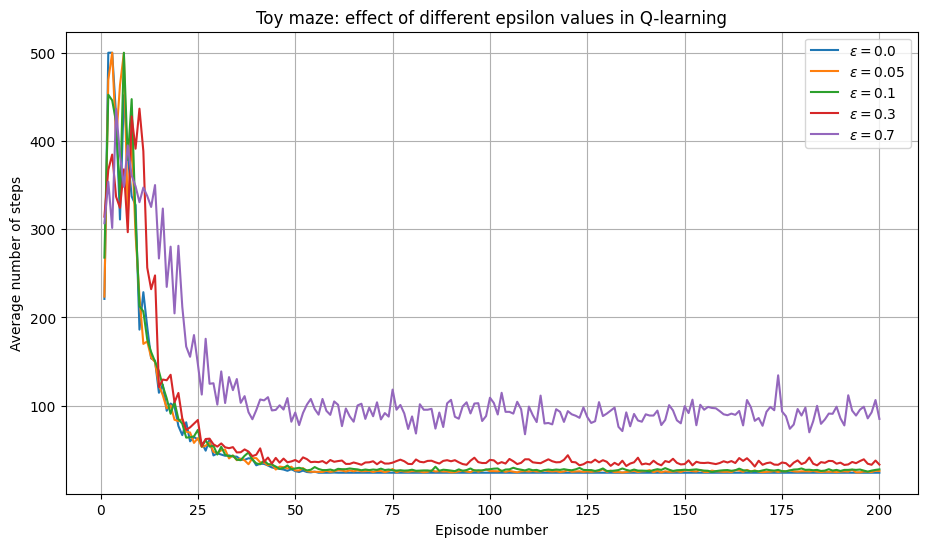

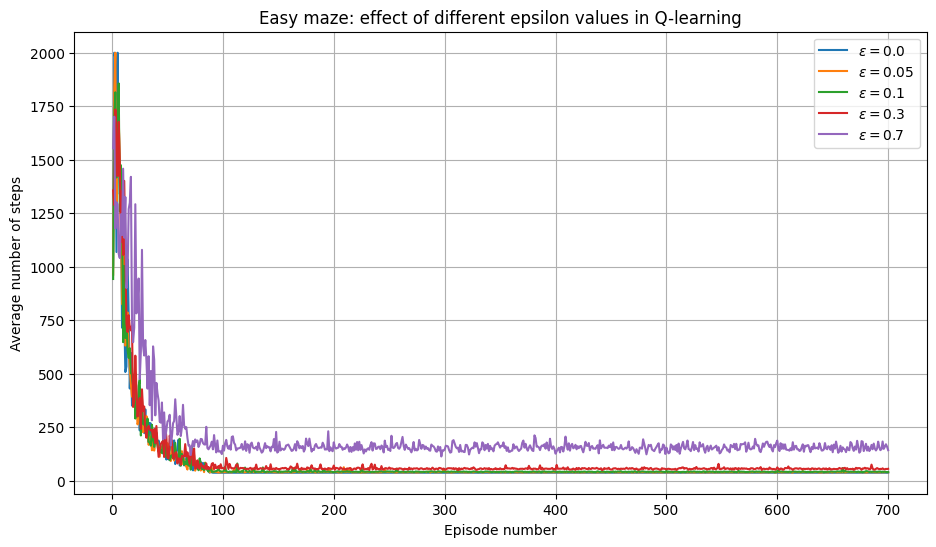

In [31]:
plot_multiple_epsilons(toy_eps_runs, "Toy maze: effect of different epsilon values in Q-learning", max_episode=200)
plot_multiple_epsilons(easy_eps_runs, "Easy maze: effect of different epsilon values in Q-learning", max_episode=700)

<div>

**Answer :**

We tested the $\varepsilon$-greedy strategy with five different values of $\varepsilon$: $0.0$, $0.05$, $0.1$, $0.3$, and $0.7$. For each value, we ran Q-learning 10 times and plotted the average number of steps per episode for both the toy maze and the easy maze.

From the plots, we can clearly see that the value of $\varepsilon$ affects the behaviour of the agent. All curves show learning, because the average number of steps decreases strongly at the beginning. However, the final performance depends on how much exploration is used.

For small values such as $\varepsilon = 0.05$ and $\varepsilon = 0.1$, the final episode lengths are relatively low. This means the agent is able to exploit the learned Q-values well while still exploring enough to discover good paths. In our experiments, $\varepsilon = 0.1$ gives a good balance between exploration and exploitation.

For larger values such as $\varepsilon = 0.3$ and especially $\varepsilon = 0.7$, the final episode lengths are clearly higher. This means the agent keeps taking too many random actions, even after it has already learned useful Q-values. As a result, it reaches the goal less efficiently.

This happens because in $\varepsilon$-greedy exploration the agent chooses a random valid action with probability $\varepsilon$ and otherwise chooses the action with the highest Q-value. So if $\varepsilon$ is too small, there is a risk of not exploring enough. But if $\varepsilon$ is too large, the agent keeps behaving too randomly and cannot fully benefit from what it has learned.

In our implementation, $\varepsilon = 0.0$ can still perform reasonably well because the Q-table is initialized optimistically. Since unexplored actions initially have high values, the agent is still encouraged to try different actions early on, even without explicit random exploration. In our experiments, moderate or small values of $\varepsilon$ worked best, while very large $\varepsilon$ led to worse performance, especially in the easy maze.

#### Question 9

<div>

**Answer :**

The main trade-off between high and low values of $\varepsilon$ is the balance between **exploration** and **exploitation**.

A **high** value of $\varepsilon$ means that the agent chooses random actions more often. The advantage is that the agent explores more of the environment and is less likely to miss potentially good paths. This is especially useful in the beginning, when the q-values are still unreliable. The disadvantage is that the agent keeps behaving quite randomly, so even later in training it may still take many unnecessary steps and perform worse on average.

A **low** value of $\varepsilon$ means that the agent chooses the greedy action more often. The advantage is that the agent can exploit what it has already learned and usually reaches the goal more efficiently. The disadvantage is that it may explore too little and get stuck with a suboptimal policy if it has not yet discovered better actions.

So, a high $\varepsilon$ helps the agent discover more, but can hurt final performance because of too much randomness. A low $\varepsilon$ improves efficiency once good q-values are known, but can hurt learning if the agent stops exploring too early. The best choice is usually a balance between the two.

#### Question 10

In [32]:
def run_qlearning_with_temperature(maze_path, total_step_limit, temperature, max_steps_per_episode=500):
    maze = Maze(maze_path)
    maze.set_reward(x=maze.width - 1, y=maze.height - 1, reward=10)
    maze.set_terminal(x=maze.width - 1, y=maze.height - 1)

    agent = Agent(start_x=0, start_y=0)

    states = maze.get_all_states()
    actions = [Action(i) for i in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions, initial_value=100)

    exploration_strategy = ExplorationStrategy(q_table)

    params = {"lr": 0.7, "gamma": 0.9}
    learner = QLearning(q_table, params)

    total_steps = 0
    episode_lengths = []

    while total_steps < total_step_limit:
        agent.reset()
        done = False
        episode_steps = 0

        while not done and total_steps < total_step_limit and episode_steps < max_steps_per_episode:
            state = agent.get_state(maze)
            action = exploration_strategy.boltzmann(agent, maze, temperature=temperature)

            if action is None:
                break

            next_state, reward, done = agent.step(action, maze)

            possible_actions = agent.get_valid_actions(maze)
            learner.learn(possible_actions, state, action, next_state, reward, done)

            episode_steps += 1
            total_steps += 1

        episode_lengths.append(episode_steps)

    return episode_lengths

In [38]:
def plot_multiple_temperatures(temp_runs_dict, title, max_episode=None):
    plt.figure(figsize=(11, 6))

    for temp, all_runs in temp_runs_dict.items():
        max_len = max(len(run) for run in all_runs)
        data = np.full((len(all_runs), max_len), np.nan)

        for i, run in enumerate(all_runs):
            data[i, :len(run)] = run

        mean_vals = np.nanmean(data, axis=0)
        x = np.arange(1, max_len + 1)

        if max_episode is not None:
            x = x[:max_episode]
            mean_vals = mean_vals[:max_episode]

        plt.plot(x, mean_vals, label=f"$T = {temp}$")

    plt.xlabel("Episode number")
    plt.ylabel("Average number of steps")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [34]:
T_values = [0.01, 0.1, 0.5, 1.0, 5.0]
n_runs = 10

toy_T_runs = {}
easy_T_runs = {}

for T in T_values:
    toy_T_runs[T] = []
    for i in range(n_runs):
        run = run_qlearning_with_temperature(
            maze_path="../data/toy_maze.txt",
            total_step_limit=30000,
            temperature=T,
            max_steps_per_episode=500
        )
        toy_T_runs[T].append(run)
    print(f"Finished toy maze for T = {T}")

for T in T_values:
    easy_T_runs[T] = []
    for i in range(n_runs):
        run = run_qlearning_with_temperature(
            maze_path="../data/easy_maze.txt",
            total_step_limit=100000,
            temperature=T,
            max_steps_per_episode=1500
        )
        easy_T_runs[T].append(run)
    print(f"Finished easy maze for T = {T}")

Finished toy maze for T = 0.01
Finished toy maze for T = 0.1
Finished toy maze for T = 0.5
Finished toy maze for T = 1.0
Finished toy maze for T = 5.0
Finished easy maze for T = 0.01
Finished easy maze for T = 0.1
Finished easy maze for T = 0.5
Finished easy maze for T = 1.0
Finished easy maze for T = 5.0


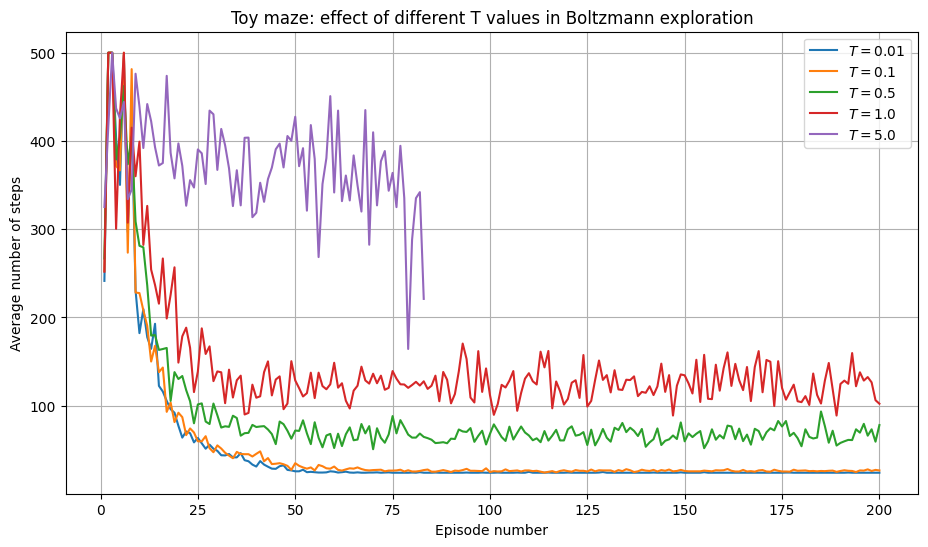

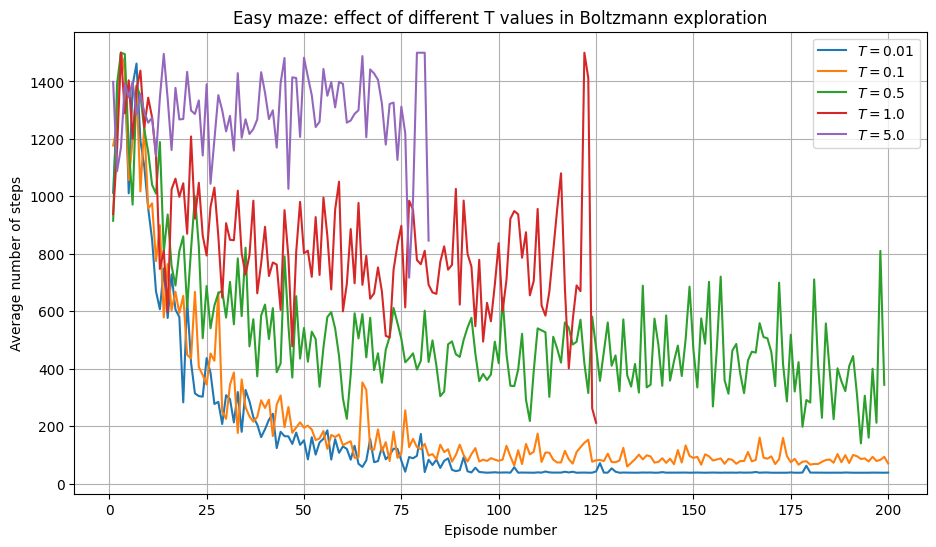

In [40]:
plot_multiple_temperatures(toy_T_runs, "Toy maze: effect of different T values in Boltzmann exploration", max_episode=200)
plot_multiple_temperatures(easy_T_runs, "Easy maze: effect of different T values in Boltzmann exploration", max_episode=200)

<div>

**Answer :**

We tested the Boltzmann exploration strategy with five different values of the temperature parameter $T$: $0.01$, $0.1$, $0.5$, $1.0$, and $5.0$. For each value, we ran Q-learning 10 times and plotted the average number of steps per episode for both the toy maze and the easy maze. For readability, we only show the first 200 episodes, because this is where the main differences between the temperature values are the easiest to see.

From the plots, we can see that the value of $T$ has a strong impact on the behaviour of the agent. Small values such as $T = 0.01$ and $T = 0.1$ perform best in our experiments. In these cases, the average number of steps drops quickly and stabilizes at a relatively low value, which means that the agent is able to use the learned Q-values well and follow a good route.

For larger values such as $T = 0.5$, $T = 1.0$, and especially $T = 5.0$, the performance is clearly worse. The average number of steps stays much higher and the learning process is much noisier. This suggests that the agent keeps exploring too much and does not make efficient use of what it has already learned.

The trade-off is that a high value of $T$ gives more exploration, because the action probabilities become more uniform. This can be useful in the beginning, when the agent still knows very little about the environment. However, if $T$ is too high, the agent keeps behaving too randomly, which hurts the final performance. A low value of $T$ makes the policy more focused on the actions with the highest Q-values, which improves efficiency once the agent has learned useful values. The downside is that if $T$ is too low, the agent may explore too little.

In our experiments, low values of $T$ worked best, while very high values led to too much randomness. So the best trade-off seems to be a low or moderate value of $T$, rather than a very high one.

#### Question 11

<div>

**Answer :**

Using the earlier experiments, we can compare the three exploration strategies: **random exploration**, **$\varepsilon$-greedy exploration**, and **Boltzmann exploration**.

The random strategy performs worst overall. It does guarantee exploration, but it completely ignores the Q-values. Because of that, even after the agent has learned useful information about the maze, it still keeps choosing actions uniformly at random. This means it cannot exploit its learned policy properly, so the average number of steps stays relatively high.

Both $\varepsilon$-greedy and Boltzmann perform much better than random exploration, because they both make use of the Q-values. However, based on our tuning experiments, **$\varepsilon$-greedy performed best overall**. With $\varepsilon$-greedy, the agent still explores enough to discover useful paths, but most of the time it exploits the action with the highest current Q-value. This gives a good balance between exploration and exploitation and leads to low final episode lengths.

Boltzmann exploration can also work well, but it is more sensitive to the choice of the temperature parameter $T$. If $T$ is too high, the policy becomes too random and the performance gets much worse. If $T$ is too low, the policy becomes almost greedy and may explore too little. In our experiments, low values of $T$ worked well, but overall the strategy seemed less robust than $\varepsilon$-greedy because the performance changed more strongly when the parameter was not chosen well.

So, the best strategy in our experiments was **$\varepsilon$-greedy exploration**. The main reason is that it is simple, stable, and gives a very direct way to control the amount of exploration. It keeps enough randomness to discover good actions, while still exploiting the learned Q-values most of the time. Random exploration does not exploit at all, and Boltzmann exploration can also work very well, but it is more sensitive to the parameter choice and therefore less consistent in practice.

#### Question 12

In [41]:
def run_qlearning_with_alpha(maze_path, total_step_limit, alpha, eps=0.1, max_steps_per_episode=500):
    maze = Maze(maze_path)
    maze.set_reward(x=maze.width - 1, y=maze.height - 1, reward=10)
    maze.set_terminal(x=maze.width - 1, y=maze.height - 1)

    agent = Agent(start_x=0, start_y=0)

    states = maze.get_all_states()
    actions = [Action(i) for i in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions, initial_value=100)

    exploration_strategy = ExplorationStrategy(q_table)

    params = {"lr": alpha, "gamma": 0.9}
    learner = QLearning(q_table, params)

    total_steps = 0
    episode_lengths = []

    while total_steps < total_step_limit:
        agent.reset()
        done = False
        episode_steps = 0

        while not done and total_steps < total_step_limit and episode_steps < max_steps_per_episode:
            state = agent.get_state(maze)
            action = exploration_strategy.e_greedy(agent, maze, eps=eps)

            if action is None:
                break

            next_state, reward, done = agent.step(action, maze)

            possible_actions = agent.get_valid_actions(maze)
            learner.learn(possible_actions, state, action, next_state, reward, done)

            episode_steps += 1
            total_steps += 1

        episode_lengths.append(episode_steps)

    return episode_lengths

In [42]:
def plot_multiple_alphas(alpha_runs_dict, title, max_episode=None):
    plt.figure(figsize=(11, 6))

    for alpha, all_runs in alpha_runs_dict.items():
        max_len = max(len(run) for run in all_runs)
        data = np.full((len(all_runs), max_len), np.nan)

        for i, run in enumerate(all_runs):
            data[i, :len(run)] = run

        mean_vals = np.nanmean(data, axis=0)
        x = np.arange(1, max_len + 1)

        if max_episode is not None:
            x = x[:max_episode]
            mean_vals = mean_vals[:max_episode]

        plt.plot(x, mean_vals, label=f"$\\alpha = {alpha}$")

    plt.xlabel("Episode number")
    plt.ylabel("Average number of steps")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [43]:
alpha_values = [0.05, 0.1, 0.3, 0.7, 0.95]
n_runs = 10

toy_alpha_runs = {}
easy_alpha_runs = {}

for alpha in alpha_values:
    toy_alpha_runs[alpha] = []
    for i in range(n_runs):
        run = run_qlearning_with_alpha(
            maze_path="../data/toy_maze.txt",
            total_step_limit=30000,
            alpha=alpha,
            eps=0.1,
            max_steps_per_episode=500
        )
        toy_alpha_runs[alpha].append(run)
    print(f"Finished toy maze for alpha = {alpha}")

for alpha in alpha_values:
    easy_alpha_runs[alpha] = []
    for i in range(n_runs):
        run = run_qlearning_with_alpha(
            maze_path="../data/easy_maze.txt",
            total_step_limit=100000,
            alpha=alpha,
            eps=0.1,
            max_steps_per_episode=1500
        )
        easy_alpha_runs[alpha].append(run)
    print(f"Finished easy maze for alpha = {alpha}")

Finished toy maze for alpha = 0.05
Finished toy maze for alpha = 0.1
Finished toy maze for alpha = 0.3
Finished toy maze for alpha = 0.7
Finished toy maze for alpha = 0.95
Finished easy maze for alpha = 0.05
Finished easy maze for alpha = 0.1
Finished easy maze for alpha = 0.3
Finished easy maze for alpha = 0.7
Finished easy maze for alpha = 0.95


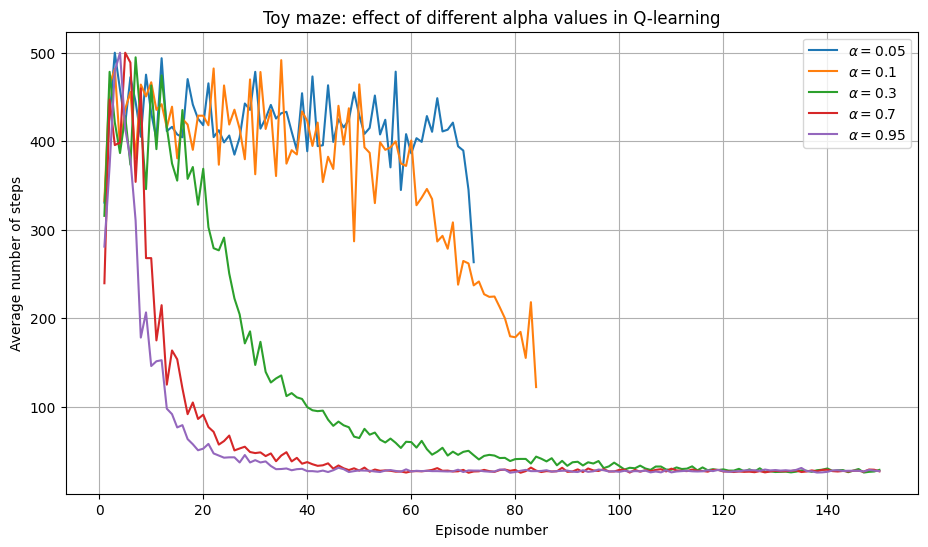

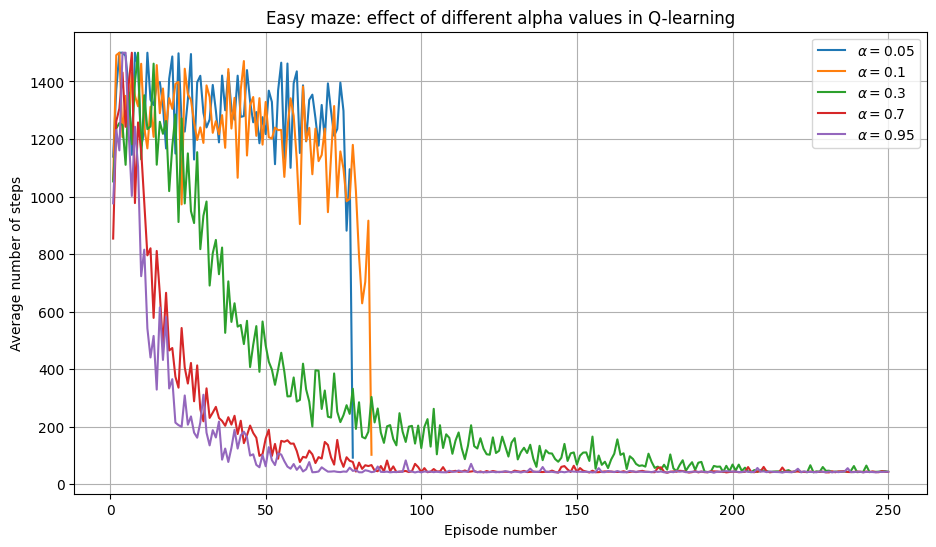

In [44]:
plot_multiple_alphas(toy_alpha_runs, "Toy maze: effect of different alpha values in Q-learning", max_episode=150)
plot_multiple_alphas(easy_alpha_runs, "Easy maze: effect of different alpha values in Q-learning", max_episode=250)

<div>

**Answer :**

We tested five different values of the learning rate $\alpha$: $0.05$, $0.1$, $0.3$, $0.7$, and $0.95$. For each value, we ran Q-learning 10 times and plotted the average number of steps per episode.

From the plots, we can clearly see that the learning rate has a strong effect on how fast the agent improves. Small values such as $\alpha = 0.05$ and $\alpha = 0.1$ lead to slow learning. In both mazes, these curves stay high for longer and only decrease after many more episodes. This means the q-values are updated only slowly.

Medium and larger values such as $\alpha = 0.3$, $\alpha = 0.7$, and $\alpha = 0.95$ lead to much faster improvement. Their curves drop much earlier, which shows that the agent learns good state-action values more quickly. In particular, $\alpha = 0.7$ and $\alpha = 0.95$ perform best in terms of learning speed.

At the same time, a very large learning rate can be slightly more aggressive. Since new experiences get a lot of weight, the q-values can change more strongly from one update to the next. This can make learning less stable, even if it is very fast. In our plots, $\alpha = 0.95$ learns very quickly, but values like $\alpha = 0.7$ seem to give a better balance between speed and stability.

This happens because $\alpha$ determines how much new information influences the q-value update. A small $\alpha$ means the agent changes its q-values only a little after each step, so learning is slow but smooth. A large $\alpha$ means the agent reacts much more strongly to recent rewards and transitions, so learning is faster, but it can also become noisier.

So the main effect of $\alpha$ is the trade-off between **learning speed** and **stability**. Low values are more stable but much slower, while high values learn faster but may be more sensitive to recent experiences. In our experiments, medium-to-high values such as $\alpha = 0.7$ gave the best overall behaviour.

### 2.3 Introducing More Rewards
#### Question 13

In [53]:
def train_qlearning_two_rewards(total_step_limit=30000, alpha=0.7, gamma=0.9, eps=0.1, max_steps_per_episode=500):
    maze = Maze("../data/toy_maze.txt")

    # original target
    maze.set_reward(x=9, y=9, reward=10)
    maze.set_terminal(x=9, y=9)

    # second target
    maze.set_reward(x=9, y=0, reward=5)
    maze.set_terminal(x=9, y=0)

    agent = Agent(start_x=0, start_y=0)

    states = maze.get_all_states()
    actions = [Action(i) for i in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions, initial_value=100)

    exploration_strategy = ExplorationStrategy(q_table)
    learner = QLearning(q_table, {"lr": alpha, "gamma": gamma})

    total_steps = 0
    episode_lengths = []

    while total_steps < total_step_limit:
        agent.reset()
        done = False
        episode_steps = 0

        while not done and total_steps < total_step_limit and episode_steps < max_steps_per_episode:
            state = agent.get_state(maze)
            action = exploration_strategy.e_greedy(agent, maze, eps=eps)

            if action is None:
                break

            next_state, reward, done = agent.step(action, maze)

            possible_actions = agent.get_valid_actions(maze)
            learner.learn(possible_actions, state, action, next_state, reward, done)

            episode_steps += 1
            total_steps += 1

        episode_lengths.append(episode_steps)

    return maze, q_table, episode_lengths


def greedy_rollout_two_rewards(q_table, max_steps=100):
    maze = Maze("../data/toy_maze.txt")

    maze.set_reward(x=9, y=9, reward=10)
    maze.set_terminal(x=9, y=9)

    maze.set_reward(x=9, y=0, reward=5)
    maze.set_terminal(x=9, y=0)

    agent = Agent(start_x=0, start_y=0)
    path = [(agent.y, agent.x)]

    for _ in range(max_steps):
        state = agent.get_state(maze)
        valid_actions = agent.get_valid_actions(maze)

        if len(valid_actions) == 0:
            break

        q_values = [q_table.get_q(state, a) for a in valid_actions]
        max_q = max(q_values)

        best_actions = [a for a, q in zip(valid_actions, q_values) if q == max_q]
        action = best_actions[np.random.choice(len(best_actions))]

        next_state, reward, done = agent.step(action, maze)
        path.append((agent.y, agent.x))

        if done:
            return (agent.x, agent.y), reward, path

    return (agent.x, agent.y), maze.get_reward(agent.x, agent.y), path


# run several times
results = []

for i in range(10):
    maze, q_table, episode_lengths = train_qlearning_two_rewards(
        total_step_limit=30000,
        alpha=0.7,
        gamma=0.9,
        eps=0.1,
        max_steps_per_episode=500
    )

    target_pos, target_reward, path = greedy_rollout_two_rewards(q_table)
    results.append((target_pos, target_reward, len(path) - 1))
    print(f"Run {i+1}: target = {target_pos}, reward = {target_reward}, path length = {len(path) - 1}")

Run 1: target = (9, 9), reward = 10, path length = 24
Run 2: target = (9, 9), reward = 10, path length = 24
Run 3: target = (9, 9), reward = 10, path length = 24
Run 4: target = (9, 9), reward = 10, path length = 24
Run 5: target = (9, 9), reward = 10, path length = 24
Run 6: target = (9, 9), reward = 10, path length = 24
Run 7: target = (9, 9), reward = 10, path length = 24
Run 8: target = (9, 9), reward = 10, path length = 24
Run 9: target = (9, 9), reward = 10, path length = 24
Run 10: target = (9, 9), reward = 10, path length = 24


Chosen target: (9, 9) reward: 10


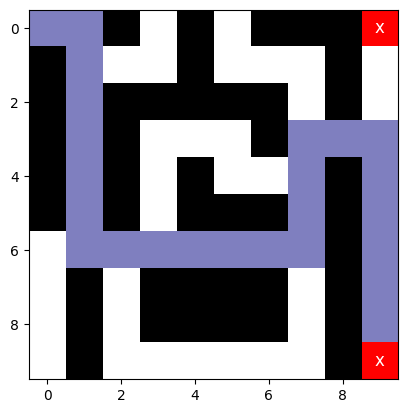

In [50]:
target_pos, target_reward, path = greedy_rollout_two_rewards(q_table)
print("Chosen target:", target_pos, "reward:", target_reward)
maze.visualize(path)

<div>

**Answer :**

Note that the maze uses array-style coordinates, so the y-coordinate increases from top to bottom. Therefore, the point $(9,0)$ corresponds to the top-right corner, while $(9,9)$ corresponds to the bottom-right corner.

After adding a second reward of $5$ at position $(9,0)$ and making it a second terminal state, we observed that in our runs the agent still converged to the bottom-right target at $(9,9)$, which gives reward $10$. So in our current setup, the larger reward remained more attractive than the smaller but closer reward.

This can be explained by the fact that Q-learning does not optimize only for the nearest reward, but for the discounted cumulative return. Even though the reward of $5$ is closer to the start, the reward of $10$ is still large enough that, with $\gamma = 0.9$, its discounted value remains better. As a result, the learned Q-values favour the path to the bottom-right corner.

So this experiment shows that the behaviour depends on the balance between reward size, distance, and discounting. In our current setting, the larger reward still dominates, even though it is farther away.

#### Question 14

In [54]:
def make_two_reward_toy_maze():
    maze = Maze("../data/toy_maze.txt")

    # reward 10 at bottom-right
    maze.set_reward(x=9, y=9, reward=10)
    maze.set_terminal(x=9, y=9)

    # reward 5 at top-right
    maze.set_reward(x=9, y=0, reward=5)
    maze.set_terminal(x=9, y=0)

    return maze


def train_qlearning_two_rewards(total_step_limit=30000, alpha=0.7, gamma=0.9, eps=0.1, max_steps_per_episode=500):
    maze = make_two_reward_toy_maze()
    agent = Agent(start_x=0, start_y=0)

    states = maze.get_all_states()
    actions = [Action(i) for i in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions, initial_value=100)

    exploration_strategy = ExplorationStrategy(q_table)
    learner = QLearning(q_table, {"lr": alpha, "gamma": gamma})

    total_steps = 0

    while total_steps < total_step_limit:
        agent.reset()
        done = False
        episode_steps = 0

        while not done and total_steps < total_step_limit and episode_steps < max_steps_per_episode:
            state = agent.get_state(maze)
            action = exploration_strategy.e_greedy(agent, maze, eps=eps)

            if action is None:
                break

            next_state, reward, done = agent.step(action, maze)
            possible_actions = agent.get_valid_actions(maze)
            learner.learn(possible_actions, state, action, next_state, reward, done)

            episode_steps += 1
            total_steps += 1

    return q_table


def train_sarsa_two_rewards(total_step_limit=30000, alpha=0.7, gamma=0.9, eps=0.1, max_steps_per_episode=500):
    maze = make_two_reward_toy_maze()
    agent = Agent(start_x=0, start_y=0)

    states = maze.get_all_states()
    actions = [Action(i) for i in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions, initial_value=100)

    exploration_strategy = ExplorationStrategy(q_table)
    learner = SARSA(q_table, {"lr": alpha, "gamma": gamma})

    total_steps = 0

    while total_steps < total_step_limit:
        agent.reset()
        done = False
        episode_steps = 0

        state = agent.get_state(maze)
        action = exploration_strategy.e_greedy(agent, maze, eps=eps)

        while not done and total_steps < total_step_limit and episode_steps < max_steps_per_episode:
            if action is None:
                break

            next_state, reward, done = agent.step(action, maze)

            next_action = None
            if not done:
                next_action = exploration_strategy.e_greedy(agent, maze, eps=eps)

            learner.learn(state, action, next_state, next_action, reward, done)

            state = next_state
            action = next_action

            episode_steps += 1
            total_steps += 1

    return q_table


def greedy_rollout_on_two_reward_maze(q_table, max_steps=100):
    maze = make_two_reward_toy_maze()
    agent = Agent(start_x=0, start_y=0)
    path = [(agent.y, agent.x)]

    for _ in range(max_steps):
        state = agent.get_state(maze)
        valid_actions = agent.get_valid_actions(maze)

        if len(valid_actions) == 0:
            break

        q_values = [q_table.get_q(state, a) for a in valid_actions]
        max_q = max(q_values)

        best_actions = [a for a, q in zip(valid_actions, q_values) if q == max_q]
        action = best_actions[np.random.choice(len(best_actions))]

        next_state, reward, done = agent.step(action, maze)
        path.append((agent.y, agent.x))

        if done:
            return (agent.x, agent.y), reward, path

    return (agent.x, agent.y), maze.get_reward(agent.x, agent.y), path


# compare both algorithms several times
qlearning_results = []
sarsa_results = []

for i in range(10):
    q_qtable = train_qlearning_two_rewards()
    q_target, q_reward, q_path = greedy_rollout_on_two_reward_maze(q_qtable)
    qlearning_results.append((q_target, q_reward, len(q_path) - 1))

    s_qtable = train_sarsa_two_rewards()
    s_target, s_reward, s_path = greedy_rollout_on_two_reward_maze(s_qtable)
    sarsa_results.append((s_target, s_reward, len(s_path) - 1))

    print(f"Run {i+1}")
    print(f"  Q-learning -> target = {q_target}, reward = {q_reward}, path length = {len(q_path) - 1}")
    print(f"  SARSA      -> target = {s_target}, reward = {s_reward}, path length = {len(s_path) - 1}")

print("\nQ-learning results:", qlearning_results)
print("SARSA results:", sarsa_results)

Run 1
  Q-learning -> target = (9, 9), reward = 10, path length = 24
  SARSA      -> target = (9, 9), reward = 10, path length = 24
Run 2
  Q-learning -> target = (9, 9), reward = 10, path length = 24
  SARSA      -> target = (9, 9), reward = 10, path length = 24
Run 3
  Q-learning -> target = (9, 9), reward = 10, path length = 24
  SARSA      -> target = (9, 9), reward = 10, path length = 24
Run 4
  Q-learning -> target = (9, 9), reward = 10, path length = 24
  SARSA      -> target = (9, 9), reward = 10, path length = 24
Run 5
  Q-learning -> target = (9, 9), reward = 10, path length = 24
  SARSA      -> target = (9, 0), reward = 5, path length = 21
Run 6
  Q-learning -> target = (9, 9), reward = 10, path length = 24
  SARSA      -> target = (9, 9), reward = 10, path length = 24
Run 7
  Q-learning -> target = (9, 9), reward = 10, path length = 24
  SARSA      -> target = (9, 9), reward = 10, path length = 24
Run 8
  Q-learning -> target = (9, 9), reward = 10, path length = 24
  SARSA 

<div>

**Answer :**

Switching from Q-learning to SARSA does not fundamentally change the outcome in our experiment. Q-learning converged to the reward of $10$ at $(9,9)$ in all 10 runs, while SARSA also chose that target in most runs and only once converged to the closer reward of $5$ at $(9,0)$. So SARSA can behave slightly differently, but it does not really solve the issue in a consistent way.

The reason is that both algorithms still optimize discounted return. If a smaller reward can be reached much faster, it can still become attractive because future rewards are discounted by $\gamma$. So the closer reward of $5$ may still compete with the further reward of $10$.

The difference between the methods comes from their update equations. Q-learning is off-policy and updates toward the value of the best possible next action, while SARSA is on-policy and updates using the next action that was actually chosen by the current policy. Because SARSA includes the effect of exploration in its updates, it is usually a bit more conservative and can sometimes prefer a safer or closer option.

This explains why SARSA in our runs once converged to the smaller reward of $5$, while Q-learning consistently preferred the reward of $10$. However, the overall conclusion is that switching to SARSA does not remove the underlying effect: both algorithms are still optimizing discounted future reward rather than simply choosing the largest raw reward.

#### Question 15

Run 1: final greedy target = (9, 9), reward = 10
Run 2: final greedy target = (9, 9), reward = 10
Run 3: final greedy target = (9, 9), reward = 10
Run 4: final greedy target = (9, 9), reward = 10
Run 5: final greedy target = (9, 9), reward = 10
Run 6: final greedy target = (9, 9), reward = 10
Run 7: final greedy target = (9, 9), reward = 10
Run 8: final greedy target = (9, 9), reward = 10
Run 9: final greedy target = (9, 9), reward = 10
Run 10: final greedy target = (9, 9), reward = 10


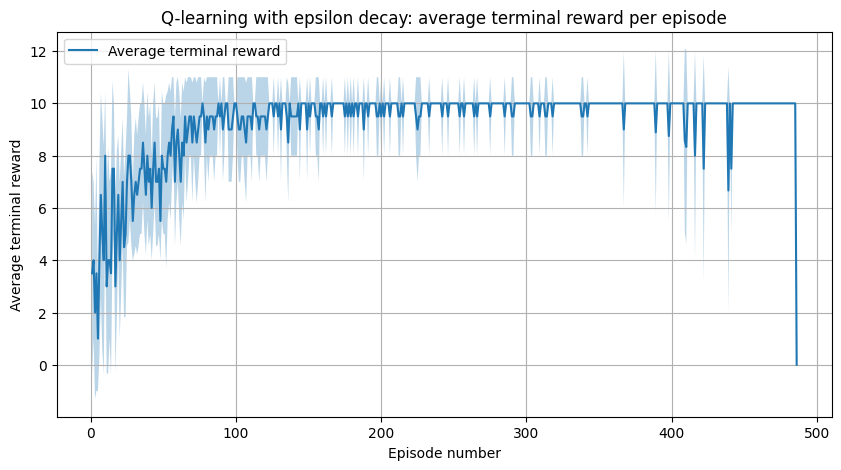

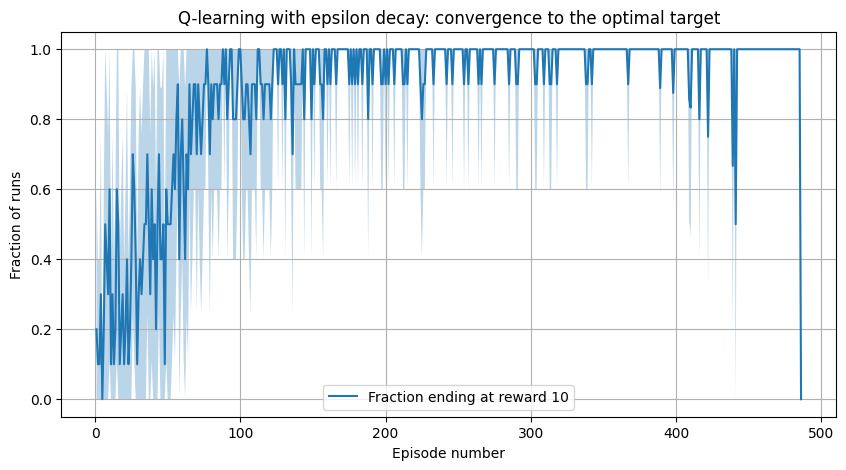

Final greedy targets across runs: [((9, 9), 10), ((9, 9), 10), ((9, 9), 10), ((9, 9), 10), ((9, 9), 10), ((9, 9), 10), ((9, 9), 10), ((9, 9), 10), ((9, 9), 10), ((9, 9), 10)]


In [55]:
def make_two_reward_toy_maze():
    maze = Maze("../data/toy_maze.txt")

    # original larger reward
    maze.set_reward(x=9, y=9, reward=10)
    maze.set_terminal(x=9, y=9)

    # closer smaller reward
    maze.set_reward(x=9, y=0, reward=5)
    maze.set_terminal(x=9, y=0)

    return maze


def run_qlearning_two_rewards_with_decay(
    total_step_limit=30000,
    alpha=0.7,
    gamma=0.9,
    eps_start=1.0,
    eps_decay=0.995,
    eps_min=0.01,
    max_steps_per_episode=500
):
    maze = make_two_reward_toy_maze()
    agent = Agent(start_x=0, start_y=0)

    states = maze.get_all_states()
    actions = [Action(i) for i in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions, initial_value=100)

    exploration_strategy = ExplorationStrategy(q_table)
    learner = QLearning(q_table, {"lr": alpha, "gamma": gamma})

    total_steps = 0
    epsilon = eps_start

    episode_lengths = []
    terminal_rewards = []
    terminal_targets = []

    while total_steps < total_step_limit:
        agent.reset()
        done = False
        episode_steps = 0
        final_reward = 0
        final_target = None

        while not done and total_steps < total_step_limit and episode_steps < max_steps_per_episode:
            state = agent.get_state(maze)
            action = exploration_strategy.e_greedy(agent, maze, eps=epsilon)

            if action is None:
                break

            next_state, reward, done = agent.step(action, maze)

            possible_actions = agent.get_valid_actions(maze)
            learner.learn(possible_actions, state, action, next_state, reward, done)

            episode_steps += 1
            total_steps += 1

            if done:
                final_reward = reward
                final_target = (next_state.x, next_state.y)

        episode_lengths.append(episode_steps)
        terminal_rewards.append(final_reward)
        terminal_targets.append(final_target)

        # epsilon decay after each episode
        epsilon = max(eps_min, epsilon * eps_decay)

    return q_table, episode_lengths, terminal_rewards, terminal_targets


def greedy_rollout_two_rewards(q_table, max_steps=100):
    maze = make_two_reward_toy_maze()
    agent = Agent(start_x=0, start_y=0)
    path = [(agent.y, agent.x)]

    for _ in range(max_steps):
        state = agent.get_state(maze)
        valid_actions = agent.get_valid_actions(maze)

        if len(valid_actions) == 0:
            break

        q_values = [q_table.get_q(state, a) for a in valid_actions]
        max_q = max(q_values)

        best_actions = [a for a, q in zip(valid_actions, q_values) if q == max_q]
        action = best_actions[np.random.choice(len(best_actions))]

        next_state, reward, done = agent.step(action, maze)
        path.append((agent.y, agent.x))

        if done:
            return (agent.x, agent.y), reward, path

    return (agent.x, agent.y), maze.get_reward(agent.x, agent.y), path


def pad_and_average(runs):
    max_len = max(len(run) for run in runs)
    data = np.full((len(runs), max_len), np.nan)

    for i, run in enumerate(runs):
        data[i, :len(run)] = run

    mean_vals = np.nanmean(data, axis=0)
    std_vals = np.nanstd(data, axis=0)
    return mean_vals, std_vals


# run several times
n_runs = 10
all_reward_runs = []
all_optimal_indicator_runs = []
final_targets = []

for i in range(n_runs):
    q_table, episode_lengths, terminal_rewards, terminal_targets = run_qlearning_two_rewards_with_decay(
        total_step_limit=30000,
        alpha=0.7,
        gamma=0.9,
        eps_start=1.0,
        eps_decay=0.995,
        eps_min=0.01,
        max_steps_per_episode=500
    )

    all_reward_runs.append(terminal_rewards)

    # 1 if episode ended at the optimal reward (9,9), else 0
    optimal_indicator = [1 if t == (9, 9) else 0 for t in terminal_targets]
    all_optimal_indicator_runs.append(optimal_indicator)

    target_pos, target_reward, path = greedy_rollout_two_rewards(q_table)
    final_targets.append((target_pos, target_reward))
    print(f"Run {i+1}: final greedy target = {target_pos}, reward = {target_reward}")

# average reward per episode
mean_rewards, std_rewards = pad_and_average(all_reward_runs)
x1 = np.arange(1, len(mean_rewards) + 1)

plt.figure(figsize=(10, 5))
plt.plot(x1, mean_rewards, label="Average terminal reward")
plt.fill_between(x1, mean_rewards - std_rewards, mean_rewards + std_rewards, alpha=0.3)
plt.xlabel("Episode number")
plt.ylabel("Average terminal reward")
plt.title("Q-learning with epsilon decay: average terminal reward per episode")
plt.grid(True)
plt.legend()
plt.show()

# fraction of runs choosing the optimal target (9,9)
mean_optimal, std_optimal = pad_and_average(all_optimal_indicator_runs)
x2 = np.arange(1, len(mean_optimal) + 1)

plt.figure(figsize=(10, 5))
plt.plot(x2, mean_optimal, label="Fraction ending at reward 10")
plt.fill_between(
    x2,
    np.maximum(0, mean_optimal - std_optimal),
    np.minimum(1, mean_optimal + std_optimal),
    alpha=0.3
)
plt.xlabel("Episode number")
plt.ylabel("Fraction of runs")
plt.title("Q-learning with epsilon decay: convergence to the optimal target")
plt.grid(True)
plt.legend()
plt.show()

print("Final greedy targets across runs:", final_targets)

<div>

**Answer :**

To mitigate the previous problem, we changed the value of $\varepsilon$ over time instead of keeping it fixed. We used an epsilon-decay strategy: the agent starts with a high value of $\varepsilon$, so it explores a lot in the beginning, and then $\varepsilon$ is gradually reduced after each episode. This means that early on the agent is encouraged to discover both reward locations, while later it becomes more greedy and exploits the better long-term option.

This helps because with a fixed exploration rate, the agent can converge too early to the closer reward of $5$ at $(9,0)$. Even though that reward is smaller, it is easier to find, so the agent may keep exploiting it before it has properly explored the better reward of $10$ at $(9,9)$. By starting with more exploration and then slowly reducing it, the agent gets enough chance to discover both options and later commit to the optimal one.

This idea is consistent with standard reinforcement learning practice. For example, the GeeksforGeeks Deep Q-Learning article explicitly states that the exploration rate should be decayed over time: “Decay Exploration Rate: Gradually decrease $\epsilon$ over time to shift from exploration to exploitation.” We use exactly this idea here, but in the tabular Q-learning setting.

The plots show that this works. The average terminal reward increases toward $10$, and the fraction of runs ending at the optimal target rises toward $1$. In addition, the final greedy evaluation confirms that all 10 runs converged to the reward of $10$ at $(9,9)$. This shows that the previous problem was successfully mitigated.

#### Question 16

gamma = 0.40 -> [((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21)]
fraction choosing smaller reward (9,0): 1.00

gamma = 0.45 -> [((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21)]
fraction choosing smaller reward (9,0): 1.00

gamma = 0.50 -> [((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21)]
fraction choosing smaller reward (9,0): 1.00

gamma = 0.55 -> [((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21)]
fraction choosing smaller reward (9,0): 1.00

gamma = 0.60 -> [((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), 

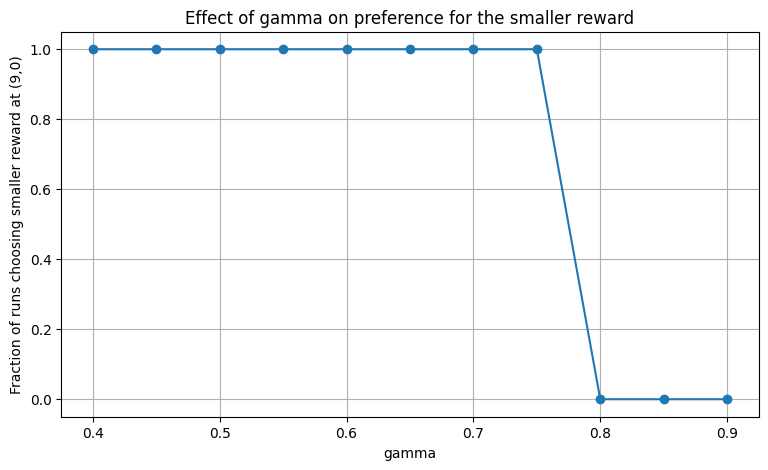

fine gamma = 0.760 -> fraction smaller reward = 1.00
fine gamma = 0.770 -> fraction smaller reward = 1.00
fine gamma = 0.780 -> fraction smaller reward = 1.00
fine gamma = 0.790 -> fraction smaller reward = 1.00
fine gamma = 0.795 -> fraction smaller reward = 0.00
fine gamma = 0.800 -> fraction smaller reward = 0.00


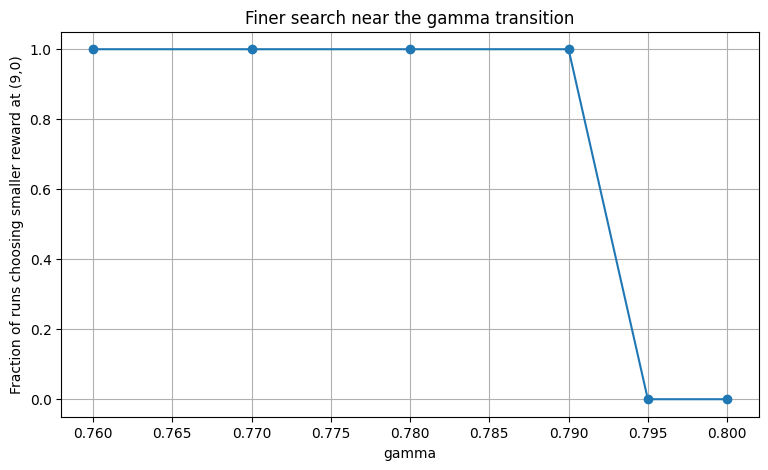

In [ ]:
#same maze as before
def make_two_reward_toy_maze():
    maze = Maze("../data/toy_maze.txt")

    # larger reward at bottom-right
    maze.set_reward(x=9, y=9, reward=10)
    maze.set_terminal(x=9, y=9)

    # smaller reward at top-right
    maze.set_reward(x=9, y=0, reward=5)
    maze.set_terminal(x=9, y=0)

    return maze


#Q-learning with epsilon decay
def train_qlearning_two_rewards_with_decay_gamma(
        gamma,
        total_step_limit=30000,
        alpha=0.7,
        eps_start=1.0,
        eps_decay=0.995,
        eps_min=0.01,
        max_steps_per_episode=500):

    maze = make_two_reward_toy_maze()
    agent = Agent(start_x=0, start_y=0)

    states = maze.get_all_states()
    actions = [Action(i) for i in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions, initial_value=100)

    exploration_strategy = ExplorationStrategy(q_table)
    learner = QLearning(q_table, {"lr": alpha, "gamma": gamma})

    total_steps = 0
    epsilon = eps_start

    while total_steps < total_step_limit:
        agent.reset()
        done = False
        episode_steps = 0

        while not done and total_steps < total_step_limit and episode_steps < max_steps_per_episode:
            state = agent.get_state(maze)
            action = exploration_strategy.e_greedy(agent, maze, eps=epsilon)

            if action is None:
                break

            next_state, reward, done = agent.step(action, maze)

            possible_actions = agent.get_valid_actions(maze)
            learner.learn(possible_actions, state, action, next_state, reward, done)

            episode_steps += 1
            total_steps += 1

        epsilon = max(eps_min, epsilon * eps_decay)

    return q_table


#greedy rollout after training
def greedy_rollout_two_rewards(q_table, max_steps=100):
    maze = make_two_reward_toy_maze()
    agent = Agent(start_x=0, start_y=0)
    path = [(agent.y, agent.x)]

    for _ in range(max_steps):
        state = agent.get_state(maze)
        valid_actions = agent.get_valid_actions(maze)

        if len(valid_actions) == 0:
            break

        q_values = [q_table.get_q(state, a) for a in valid_actions]
        max_q = max(q_values)

        best_actions = [a for a, q in zip(valid_actions, q_values) if q == max_q]
        action = best_actions[np.random.choice(len(best_actions))]

        next_state, reward, done = agent.step(action, maze)
        path.append((agent.y, agent.x))

        if done:
            return (agent.x, agent.y), reward, len(path) - 1, path

    return (agent.x, agent.y), maze.get_reward(agent.x, agent.y), len(path) - 1, path


#experimental gamma sweep
gamma_values = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
n_runs = 10

gamma_results = {}
fraction_small_reward = []

for gamma in gamma_values:
    results_for_gamma = []

    for i in range(n_runs):
        q_table = train_qlearning_two_rewards_with_decay_gamma(
            gamma=gamma,
            total_step_limit=30000,
            alpha=0.7,
            eps_start=1.0,
            eps_decay=0.995,
            eps_min=0.01,
            max_steps_per_episode=500
        )

        target_pos, target_reward, path_length, path = greedy_rollout_two_rewards(q_table)
        results_for_gamma.append((target_pos, target_reward, path_length))

    gamma_results[gamma] = results_for_gamma

    # count how often the smaller reward (9,0) is chosen
    small_count = sum(1 for target_pos, reward, _ in results_for_gamma if target_pos == (9, 0))
    fraction_small = small_count / n_runs
    fraction_small_reward.append(fraction_small)

    print(f"gamma = {gamma:.2f} -> {results_for_gamma}")
    print(f"fraction choosing smaller reward (9,0): {fraction_small:.2f}\n")


#plot
plt.figure(figsize=(9, 5))
plt.plot(gamma_values, fraction_small_reward, marker="o")
plt.xlabel("gamma")
plt.ylabel("Fraction of runs choosing smaller reward at (9,0)")
plt.title("Effect of gamma on preference for the smaller reward")
plt.grid(True)
plt.show()


#finer sweep near transition
fine_gamma_values = [0.76, 0.77, 0.78, 0.79, 0.795, 0.80]
fine_fraction_small = []

for gamma in fine_gamma_values:
    small_count = 0

    for i in range(n_runs):
        q_table = train_qlearning_two_rewards_with_decay_gamma(
            gamma=gamma,
            total_step_limit=30000,
            alpha=0.7,
            eps_start=1.0,
            eps_decay=0.995,
            eps_min=0.01,
            max_steps_per_episode=500
        )

        target_pos, target_reward, path_length, path = greedy_rollout_two_rewards(q_table)

        if target_pos == (9, 0):
            small_count += 1

    frac = small_count / n_runs
    fine_fraction_small.append(frac)
    print(f"fine gamma = {gamma:.3f} -> fraction smaller reward = {frac:.2f}")

plt.figure(figsize=(9, 5))
plt.plot(fine_gamma_values, fine_fraction_small, marker="o")
plt.xlabel("gamma")
plt.ylabel("Fraction of runs choosing smaller reward at (9,0)")
plt.title("Finer search near the gamma transition")
plt.grid(True)
plt.show()

<div>

**Answer :**

Using the epsilon-decay solution from Question 15, we experimentally searched for a value of $\gamma$ for which the agent prefers the smaller reward of $5$ at $(9,0)$ instead of the larger reward of $10$ at $(9,9)$.

From the coarse experiment, we found that the transition happens between $\gamma = 0.75$ and $\gamma = 0.80$. We then refined the search around that interval and found that the switch happens between $\gamma = 0.790$ and $\gamma = 0.795$. So experimentally, the critical value is approximately $\gamma \approx 0.794$.

We can confirm this value with a derivation. From the greedy rollouts, the path to the smaller reward has length $21$ steps, while the path to the larger reward has length $24$ steps. Since the reward is only obtained at the terminal state, the discounted returns are:

- smaller reward: $5\gamma^{20}$
- larger reward: $10\gamma^{23}$

The threshold is the value of $\gamma$ for which both discounted returns are equal:

$5\gamma^{20} = 10\gamma^{23}$

Dividing both sides by $5\gamma^{20}$ gives:

$1 = 2\gamma^3$

so

$\gamma^3 = \frac{1}{2}$

and therefore

$\gamma = \left(\frac{1}{2}\right)^{1/3} \approx 0.794$.

This matches the experimental results very well, because our finer search showed that the switch occurs between $0.790$ and $0.795$. Therefore, the critical value is approximately $\gamma \approx 0.794$.

So the conclusion is that if $\gamma$ is below this value, the smaller but closer reward is optimal under discounting, while if $\gamma$ is above this value, the larger but further reward becomes optimal.

## 3. Open Questions
### 3.1 Reflection
#### Question 17

<div>

Give at least one downside of an algorithm that is greedy with its action selection.

***ANSWER:***
There has to be a discussion between the importance of exploration vs exploitation in the context of Reinforcement Learning. An algorithm that is purely greedy with its action selection completely ignores the former and focuses on the latter. This would imply mathematically choosing the action that maximizes the highest option out of all currently known Q-values. Due to the fact that it never bothers to check unvisited or currently "lower value" states, it risks getting stuck in a **local optimum**. For *example*, a grocery shop agent might get stuck in an unnecessarily long path that eventually reaches the target inefficiently because the unknown aisle currently had a Q-value of 0.

#### Question 18

<div>

When and why can reward functions cause problems in the society? Think in terms of
agents “understanding” the point of their reward functions.

***ANSWER:*** According to **Felix Hofstätter** in ***"How learning reward functions can go wrong"***, reward functions can be problematic through ***Specification Gaming***. Such a phenomenon appears when the objective's definition may not accurately capture the human's intention. To give a real-world example of how there might be unwanted behaviours, researchers at OpenAI once trained an RL agent on the game CoastRunners, which is about a motorboat race. In a textbook example of misspecified reward, the game does not reward the agent for its progression along the track, but for hitting targets laid out along the track. This loophole was exploited by the agent who found a strategy for hitting targets without finishing the race. At a societal level, a social media algorithm might act similarly by maximizing clicks and completely ignoring the true human intent of fostering a healthy community.

#### Question 19

<div>

Can you think of a way to overcome these problems for reward functions, used in practice?

***ANSWER:*** According to ***"Reward Shaping to Mitigate Reward Hacking in RLHF"***, a good solution for such problems would be ***RLHF (Reinforcement Learning from Human Feedback)***. Basically, it is a way to teach an AI how to behave by using human preferences. In the process, humans rank AI responses to train a secondary "judge" model that learns human preferences. The main AI is then optimized through reinforcement learning to maximize its score from this judge, ultimately producing safer and more helpful outputs. For example, according to https://openai.com/index/instruction-following/, OpenAI used this technology for ChatGPT.

### 3.2 Pen and Paper
#### Question 20

<div>

***ANSWER:***

![alt text](<WhatsApp Image 2026-04-07 at 14.01.51.jpeg>) 


***REST of the graph:***


![alt text](<WhatsApp Image 2026-04-07 at 14.01.51 (1).jpeg>) 

![alt text](<WhatsApp Image 2026-04-07 at 14.01.51 (2).jpeg>)

#### Question 21

<div>

***ANSWER:***

![alt text](<WhatsApp Image 2026-04-07 at 14.05.25-1.jpeg>)![alt text](<WhatsApp Image 2026-04-07 at 14.05.25 (1).jpeg>) ![alt text](<WhatsApp Image 2026-04-07 at 14.05.25 (2).jpeg>) ![alt text](<WhatsApp Image 2026-04-07 at 14.05.25 (3).jpeg>) ![alt text](<WhatsApp Image 2026-04-07 at 14.05.25 (4).jpeg>) ![alt text](<WhatsApp Image 2026-04-07 at 14.05.25 (5).jpeg>) ![alt text](<WhatsApp Image 2026-04-07 at 14.05.25 (6).jpeg>) ![alt text](<WhatsApp Image 2026-04-07 at 14.05.25 (7).jpeg>) ![alt text](<WhatsApp Image 2026-04-07 at 14.05.25 (8).jpeg>) 

#### Question 22

<div>

***ANSWER:***

![alt text](<WhatsApp Image 2026-04-07 at 14.06.30.jpeg>)![alt text](<WhatsApp Image 2026-04-07 at 14.06.30 (1).jpeg>) ![alt text](<WhatsApp Image 2026-04-07 at 14.06.31.jpeg>) 

### 3.3 Division of Work

#### Question 23

<div>


|          Component          |   Luca Tuluș   |  Szymon Krętowski   |  Hristo Bozhkov   |  Kamil Wawszczak   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     30%     |     40%     |     15%     |     15%     |
| Code (implementation)       |     20%     |     30%     |     20%     |     30%     |
| Code (validation)           |     25%     |     25%     |     20%     |     30%     |
| Experiments (execution)     |     20%     |     10%     |     30%     |     40%     |
| Experiments (analysis)      |     25%     |     25%     |     25%     |     25%     |
| Experiments (visualization) |     30%     |     20%     |     20%     |     30%     |
| Report (original draft)     |     40%     |     20%     |     20%     |     20%     |
| Report (reviewing, editing) |     10%     |     40%     |     30%     |     20%     |


### References

<div>

**If you made use of any non-course resources, cite them below.**

***Question 5:***
Help from Ai with generating tests

***Question 8,10,12:***
Help from Ai with increasing the readability of the plots

***Question 15:***
https://www.geeksforgeeks.org/deep-learning/deep-q-learning/

***Question 18:***
https://medium.com/data-science/how-learning-reward-functions-can-go-wrong-6e794e42f4fc
https://www.youtube.com/watch?v=tlOIHko8ySg

***Question 19:***
https://arxiv.org/html/2502.18770v2
https://openai.com/index/instruction-following/